<font size="10">**Tarea 2**</font>

<u> *Instrucciones* </u>

Los resultados de los ejericicios propuestos se deben entregar como un notebook por correo electronico a *juancaros@udec.cl* el dia 20/5 hasta las 21:00. Es importante considerar que el código debe poder ejecutarse en cualquier computadora con la data original del repositorio. Recordar la convencion para el nombre de archivo ademas de incluir en su documento titulos y encabezados por seccion. 

El archivo a utilizar es *panel_eps.csv*, que contiene un resumen de la Encuesta de Proteccion Social, en particular la caracterizacion de los individuos en distintas rondas, su situacion laboral y de salud. 

**Variable dictionary**

- num-folio_n20:	identificacion individuo
- num-year:	anio 20xx
- cat?-time:	ronda de la encuesta (1-7)
- num -age:	edad
- bin-hombre:	1 si hombre, 0 mujer
- num -edu:	educacion medida en anios completados
- cat-region:	region (1-16)
- cat-status:	1 casado 2 convive 3 divorciado 4 viudo 5 soltero
- bin-kids:	1 if has kids, 0 ow
- num -children:	#of children under 18 years old, 18 included
- cat-situation:	1 otro, 2 cesante, 3 trabajando, 4 inactivo
- cat-lmp:	1 part-time worker, 2 full-time worker, 0 not working
- num -exp:	years of labor experience
- num -size:	tamanio de la firma
- cat¿-occupation:	codigo ocupacion
- num -wage:	salario mensual en pesos del anio encuesta
- num -hours:	horas semanales trabajadas
- bin-informal:	1 if no work contract, 0 ow
- bin-selfemp:	1 if self employed, 0 ow
- bin-publicemp:	1 if worker in public sector, 0 ow
- bin-sistema:	1 if in AFP system, 0 ow
- bin-cotizando:	1 if contributor, 0 ow
- num -assets:	accumulated wealth in pension system, pesos of each year
- num -exp_sist:	years of experience in pension system
- num -expectancy:	expectativa de vida autorreportada
- bin-illness:	1 si tiene al menos una enferdad, 0 si no
- bin-cronica:	Si tiene enfermedad cronica 1, 0 eoc
- bin-nocronica:	Si tiene enfermedad no cronica 1, 0 eoc
- bin-mental:	Si tiene enfermedad mental 1, 0 eoc


Preguntas:

1. Cargar la base de datos en el ambiente. Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn
import scipy 
from scipy.stats import nbinom
import seaborn as sns
from statsmodels.iolib.summary2 import summary_col
import math
import warnings
warnings.filterwarnings("ignore")
import linearmodels.panel as lmp
import numpy.linalg as la
from scipy import stats


In [2]:
#Cargar la data
df=pd.read_csv("DATA/panel_eps.csv", delimiter="," ,header=0)
df_02=df.copy()
df_02

,folio_n20,year,time,edad,hombre,edu,region,status,kids,children,...,fondob,fondoc,fondod,fondoe,exp_sist,expectancy,illness,cronica,nocronica,mental
0,124560204870,4,2,49,0.0,7.0,5.0,3.0,1,1.0,...,NaN,NaN,NaN,NaN,0,58.0,1.0,0.0,1.0,0.0
1,124560204870,6,3,51,0.0,4.0,5.0,3.0,1,1.0,...,NaN,NaN,NaN,NaN,0,55.0,0.0,0.0,0.0,0.0
2,124560204870,9,4,54,0.0,5.0,5.0,3.0,1,1.0,...,NaN,NaN,NaN,NaN,0,70.0,1.0,0.0,0.0,1.0
3,124560204870,12,5,57,0.0,4.0,NaN,5.0,0,0.0,...,NaN,NaN,NaN,NaN,0,70.0,1.0,0.0,0.0,0.0
4,124560205935,2,1,1982,0.0,15.0,13.0,3.0,1,4.0,...,NaN,NaN,NaN,NaN,19,75.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96841,128133653188,12,5,1992,0.0,16.0,NaN,3.0,0,0.0,...,NaN,NaN,NaN,NaN,7,80.0,0.0,0.0,0.0,0.0
96842,128133692735,12,5,1992,0.0,12.0,NaN,2.0,0,0.0,...,NaN,NaN,NaN,NaN,7,80.0,1.0,0.0,0.0,0.0
96843,128133702320,12,5,1992,0.0,15.0,NaN,5.0,0,0.0,...,NaN,NaN,NaN,NaN,7,75.0,0.0,0.0,0.0,0.0
96844,128133728022,12,5,1992,0.0,8.0,NaN,2.0,0,0.0,...,NaN,NaN,NaN,NaN,6,70.0,1.0,0.0,0.0,0.0


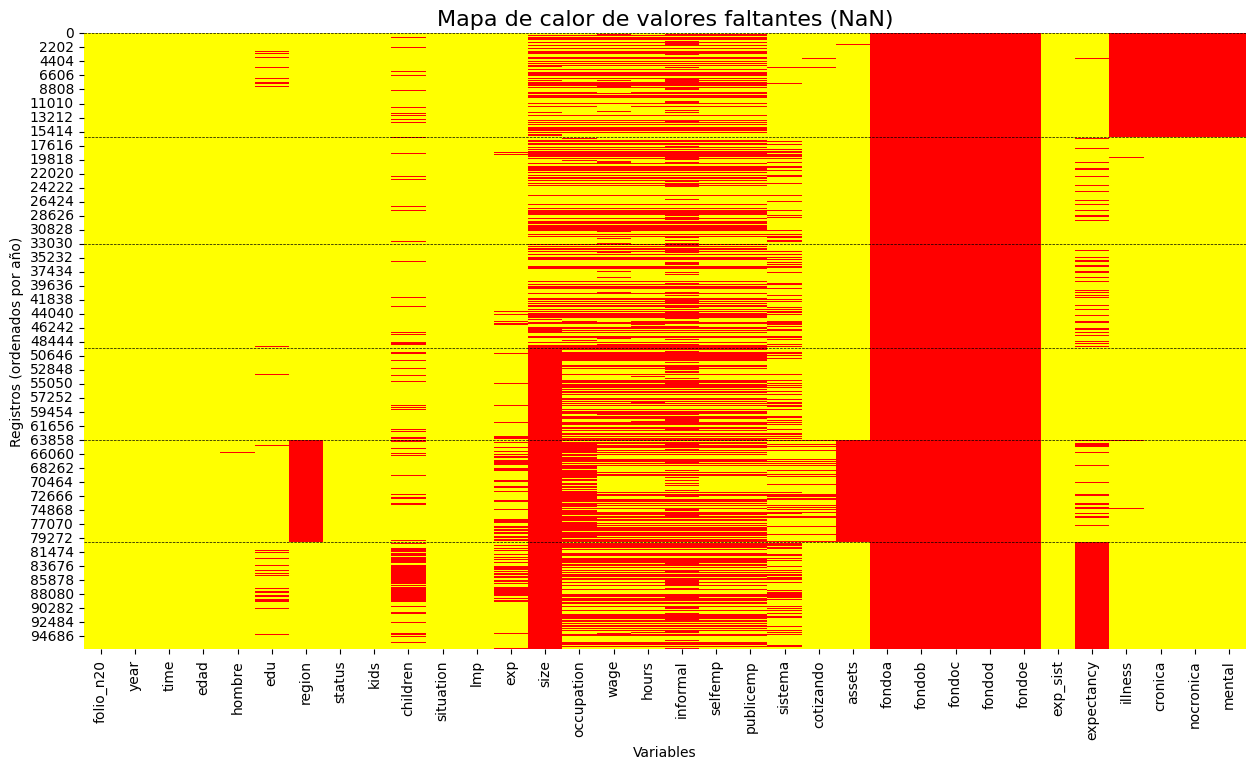

In [3]:
#REALIZAMOS UN GRAFICO PARA ANALIZAR PROPORCIONES DE NAN SEGUN VARIABLE SEPARADO POR UNA LINEA SEGUN RONDA

#Asegurarte de que esté ordenado por año
df_02_sorted=df_02.sort_values(by='year').reset_index(drop=True)

#Encontrar los índices donde cambia el año
cambios_de_anio=df_02_sorted['year'].ne(df_02_sorted['year'].shift()).cumsum()
lineas_de_corte=df_02_sorted.groupby(cambios_de_anio).head(1).index.tolist()

#Generar el heatmap
plt.figure(figsize=(15, 8))
sns.heatmap(df_02_sorted.isnull(), cbar=False, cmap=sns.color_palette(["yellow", "red"]))
plt.title("Mapa de calor de valores faltantes (NaN)", fontsize=16)
plt.xlabel("Variables")
plt.ylabel("Registros (ordenados por año)")

#Dibujar líneas horizontales donde cambia el año
for i in lineas_de_corte:
    plt.axhline(i, color='black', linestyle='--', linewidth=0.5)

plt.show()

In [4]:
#Eliminamos las columnas fondos por que estan 100% compuestas por NaN
#y luego ordenamos el df por año para hacerlo mas amigable visualmente

df_02=df_02.drop(['fondoa','fondob','fondoc','fondod','fondoe'],axis=1)
df_02=df_02.sort_values(by=['year'])

In [5]:
#Rellenamos con 0 los NaN de la columna children, asumiendo que si lo dejaron en blanco no tienen hijos
#Y tambien las columnas 'size', 'occupation', 'wage', 'hours', 'informal', 'selfemp' y 'publicemp', en el caso que situación sea 4(inactivo), dado qe gran parte de los 
#valores nan de aquellas columnas coincidian con esa situacion 
df_02['children']=df_02['children'].fillna(0)
columnas_objetivo=['size', 'occupation', 'wage', 'hours', 'informal', 'selfemp', 'publicemp']
df_02.loc[df_02['situation']==4, columnas_objetivo]=df_02.loc[df_02['situation']==4, columnas_objetivo].fillna(0)


In [6]:
#Tranajamos la columna expectancy para que tome valores NaN si el valor es 888 o 999(errores por default), y posteriromente, en caso de que tengan siguiente valor dentro 
#del mismo folio hacemos que los nan asuman ese valor,y  sino que asuman el anterior, le damos prioridad al siguiente sobre el anterior, dado que habla de una estimación 
#mas reciente que tuvo el individuo y se puede acercar mas a lo que cree y sino la anterior pensando que puede tener una estimación similar

df_02['expectancy']=df_02['expectancy'].replace([999, 888], np.nan)
df_02['expectancy']=df_02.groupby('folio_n20')['expectancy'].fillna(method='bfill')
df_02['expectancy']=df_02.groupby('folio_n20')['expectancy'].fillna(method='ffill')


In [7]:
#Para el trabajo de las siguientes columnas se establecen indicadores porcentuales antes y despues de las modificaciones para estimar la diferencia de impacto 
#en su proporción d NaN

#TRABAJAMOS COLUMNA REGION
#INDICADOR % NAN ENTRADA
col='region'
porcentaje=df_02[col].isna().mean()*100
print(f"Antes {col}: {porcentaje:.2f}% NaN")

#Generamos nuevas columnas para facilitar analisis de regiones
df_02['region_prev']=df_02.groupby('folio_n20')['region'].shift(1)
df_02['region_next']=df_02.groupby('folio_n20')['region'].shift(-1)

#Lógica: si region es NaN y prev==next, entonces el individuo se mantuvo en una misma region, tomar ese valor
condicion=df_02['region'].isna() & (df_02['region_prev']==df_02['region_next'])
df_02.loc[condicion, 'region']=df_02.loc[condicion, 'region_prev']

#Eliminamos columnas auxiliares
df_02.drop(columns=['region_prev', 'region_next'], inplace=True)

#INDICADOR % NAN SALIDA
col='region'
porcentaje=df_02[col].isna().mean()*100
print(f"Despues {col}: {porcentaje:.2f}% NaN")

Antes region: 16.52% NaN
Despues region: 9.72% NaN


In [8]:
#TRABAJAMOS COLUMNA ASSETS
#INDICADOR % NAN ENTRADA
col='assets'
porcentaje=df_02[col].isna().mean()*100
print(f"Antes {col}: {porcentaje:.2f}% NaN")

#Crear columnas auxiliares: valor anterior y siguiente por id
df_02['assets_prev']=df_02.groupby('folio_n20')['assets'].shift(1)
df_02['assets_next']=df_02.groupby('folio_n20')['assets'].shift(-1)

#Condición: assets es NaN, pero tiene valores válidos antes y después
cond=df_02['assets'].isna() & df_02['assets_prev'].notna() & df_02['assets_next'].notna()

#Reemplazar NaN con el promedio entre anterior y siguiente, asumiendo que sigue una distribución lineal
df_02.loc[cond, 'assets']=(df_02.loc[cond, 'assets_prev']+df_02.loc[cond, 'assets_next']) / 2

#Eliminar columnas auxiliares si ya no se necesitan
df_02.drop(columns=['assets_prev', 'assets_next'], inplace=True)

#INDICADOR % NAN SALIDA
col='assets'
porcentaje=df_02[col].isna().mean()*100
print(f"Despues {col}: {porcentaje:.2f}% NaN")

Antes assets: 16.61% NaN
Despues assets: 9.62% NaN


In [9]:
#Para posteriores analisis generamos una columna binaria llamada "cambio_trabajo", que toma el valor de 1 si se cree que el individuo cambió de trabajo y 0 si no
#Esta se genera en base a ciertas evidencias, como si el individuo cambia de ocupación, tipo de empleo, tamaño de empresa(cambió de empresa), entre otros.
#Para ello creamos columnas de diferencia por individuo
df_02['ocupacion_cambio']=df_02.groupby('folio_n20')['occupation'].diff().ne(0)
df_02['empresa_cambio']=df_02.groupby('folio_n20')['size'].diff().ne(0)
df_02['tipo_empleo_cambio']=df_02.groupby('folio_n20')['lmp'].diff().ne(0)
df_02['sector_cambio']=df_02.groupby('folio_n20')[['informal', 'publicemp', 'selfemp']].diff().abs().sum(axis=1) > 0

#Creamos columna cambio_trabajo y eliminamos auxiliares
df_02['cambio_trabajo']=df_02[['ocupacion_cambio', 'empresa_cambio', 'tipo_empleo_cambio', 'sector_cambio']].any(axis=1)
df_02.drop(columns=['ocupacion_cambio', 'empresa_cambio', 'tipo_empleo_cambio', 'sector_cambio'], inplace=True)

In [10]:
#TRABAJAMOS COLUMNA EXP

#INDICADOR DE ENTRADA
col='exp'
porcentaje=df_02[col].isna().mean()*100
print(f"antes {col}: {porcentaje:.2f}% NaN")

#En el caso que se haya detectado un cambio de trabajo y la columna exp sea NaN, se asume que tiene experiencia 0 al ser un nuevo trabajo
condicion=(df_02['cambio_trabajo']==1) & (df_02['exp'].isna())
df_02.loc[condicion, 'exp']=0

#INDICADOR DE SALIDA
col='exp'
porcentaje=df_02[col].isna().mean()*100
print(f"despues {col}: {porcentaje:.2f}% NaN")

antes exp: 12.37% NaN
despues exp: 0.65% NaN


In [11]:
#Se intentaron hacer analisis para trabajar size de manera adecuada, pero no se logro ningun cambio en la proporción de nan, por lo tanto columna se mantiene igual
#INDICADOR CAMBIO 0
col='size'
porcentaje=df_02[col].isna().mean()*100
print(f"Antes {col}: {porcentaje:.2f}% NaN")

#Ordenar por individuo y tiempo (aquí se asume que 'year' y 'time' definen el orden temporal)
df_02=df_02.sort_values(by=['folio_n20', 'year', 'time'])

#Obtener el valor de 'size' de la siguiente fila por individuo
df_02['size_next']=df_02.groupby('folio_n20')['size'].shift(-1)
df_02['cambio_next']=df_02.groupby('folio_n20')['cambio_trabajo'].shift(-1)

#Condición para rellenar
cond=(df_02['size'].isna() &(df_02['cambio_trabajo']==1) &df_02['size_next'].notna() &(df_02['cambio_next']==0))

#Rellenar el NaN con el valor de la siguiente fila
df_02.loc[cond, 'size']=df_02.loc[cond, 'size_next']

#Limpiar columnas auxiliares
df_02.drop(columns=['size_next', 'cambio_next'], inplace=True)

#INDICADOR CAMBIO 1
col='size'
porcentaje=df_02[col].isna().mean()*100
print(f"En medio 1 {col}: {porcentaje:.2f}% NaN")

#Suponiendo que df_02 ya está ordenado por ['folio_n20', 'year', 'time']

#Obtener el valor anterior de 'size' y 'cambio_trabajo' por individuo
df_02['size_prev']=df_02.groupby('folio_n20')['size'].shift(1)
df_02['cambio_prev']=df_02.groupby('folio_n20')['cambio_trabajo'].shift(1)

#Condición para rellenar
cond=(df_02['size'].isna() &(df_02['cambio_trabajo']==0) &(df_02['cambio_prev']==0) &df_02['size_prev'].notna())

#Rellenar NaN con el valor anterior
df_02.loc[cond, 'size']=df_02.loc[cond, 'size_prev']

#Limpiar columnas auxiliares si quieres
df_02.drop(columns=['size_prev', 'cambio_prev'], inplace=True)

#INDICADOR CAMBIO 2
col='size'
porcentaje=df_02[col].isna().mean()*100
print(f"En medio 2 {col}: {porcentaje:.2f}% NaN")

df_02=df_02.sort_values(by=['folio_n20', 'year', 'time'])
df_02['segmento']=df_02.groupby('folio_n20')['cambio_trabajo'].cumsum()
#Usar transform en vez de apply para preservar el índice
df_02['size_filled']=df_02.groupby(['folio_n20', 'segmento'])['size'].transform(lambda x: x.ffill().bfill())
df_02['size']=df_02['size'].fillna(df_02['size_filled'])
df_02.drop(columns=['segmento', 'size_filled'], inplace=True)

#INDICADOR CAMBIO 3
col='size'
porcentaje=df_02[col].isna().mean()*100
print(f"Despues {col}: {porcentaje:.2f}% NaN")

Antes size: 36.24% NaN
En medio 1 size: 36.24% NaN
En medio 2 size: 36.24% NaN
Despues size: 36.24% NaN


In [12]:
#REVISAMOS LA  MANTENCIÓN DE LAS PERSONAS EN LAS RONDAS PARA TENER UNA NOCIÓN DE CUANTAS TIENDEN A DURAR

#Ordenar por persona y tiempo
df_02=df_02.sort_values(by=['folio_n20', 'year', 'time']).reset_index(drop=True)

#Detectar primera y última aparición por persona
df_02['es_entrada']=df_02['folio_n20'] !=df_02['folio_n20'].shift(1)
df_02['es_salida']=df_02['folio_n20'] !=df_02['folio_n20'].shift(-1)

#Contar cuántas veces aparece cada persona (cuántas rondas tiene)
rondas_por_persona=df_02.groupby('folio_n20').size()

#Contar cuántas personas estuvieron N rondas
conteo_rondas=rondas_por_persona.value_counts().sort_index()

#Calcular porcentaje
porcentaje_rondas=(conteo_rondas / rondas_por_persona.shape[0])*100

#Crear DataFrame resumen
resumen_duracion=pd.DataFrame({'rondas': conteo_rondas.index,'cantidad_personas': conteo_rondas.values,'porcentaje': porcentaje_rondas.values})

#Mostrar
print(resumen_duracion)


   rondas  cantidad_personas  porcentaje
0       1              14784   44.153750
1       2               1944    5.805931
2       3               2902    8.667085
3       4               4203   12.552639
4       5               5244   15.661679
5       6               4406   13.158916


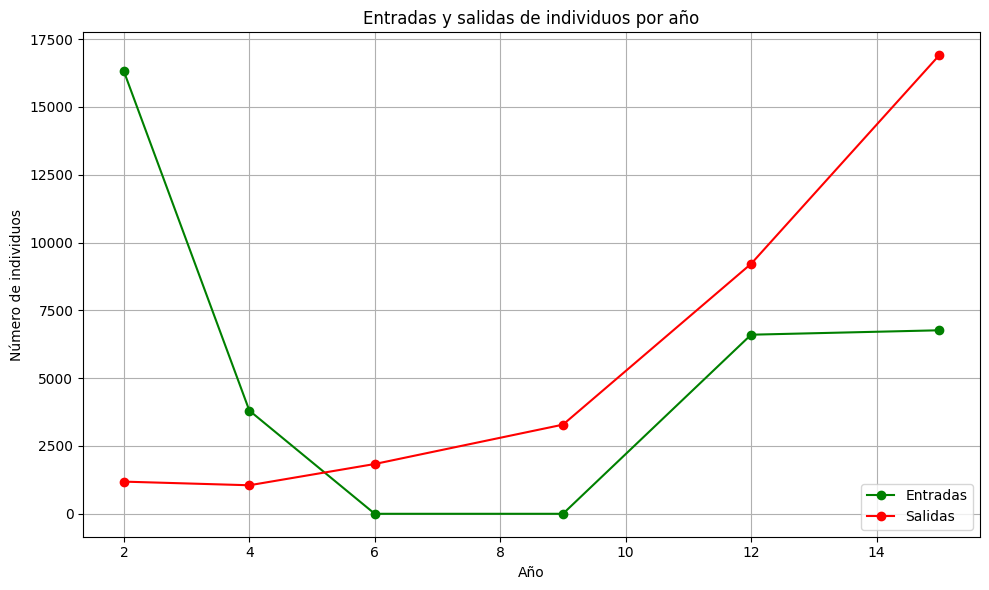

In [13]:
#Contar entradas y salidas por año
entradas_por_anio=df_02[df_02['es_entrada']].groupby('year').size()
salidas_por_anio=df_02[df_02['es_salida']].groupby('year').size()

#Asegurar que ambos tengan los mismos años (rellenar con 0 donde falte)
todos_los_anios=sorted(df_02['year'].unique())
entradas_por_anio=entradas_por_anio.reindex(todos_los_anios, fill_value=0)
salidas_por_anio=salidas_por_anio.reindex(todos_los_anios, fill_value=0)

#Graficar
plt.figure(figsize=(10, 6))
plt.plot(entradas_por_anio.index, entradas_por_anio.values, marker='o', label='Entradas', color='green')
plt.plot(salidas_por_anio.index, salidas_por_anio.values, marker='o', label='Salidas', color='red')
plt.title('Entradas y salidas de individuos por año')
plt.xlabel('Año')
plt.ylabel('Número de individuos')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

df_02.drop(columns=['es_entrada', 'es_salida'], inplace=True)


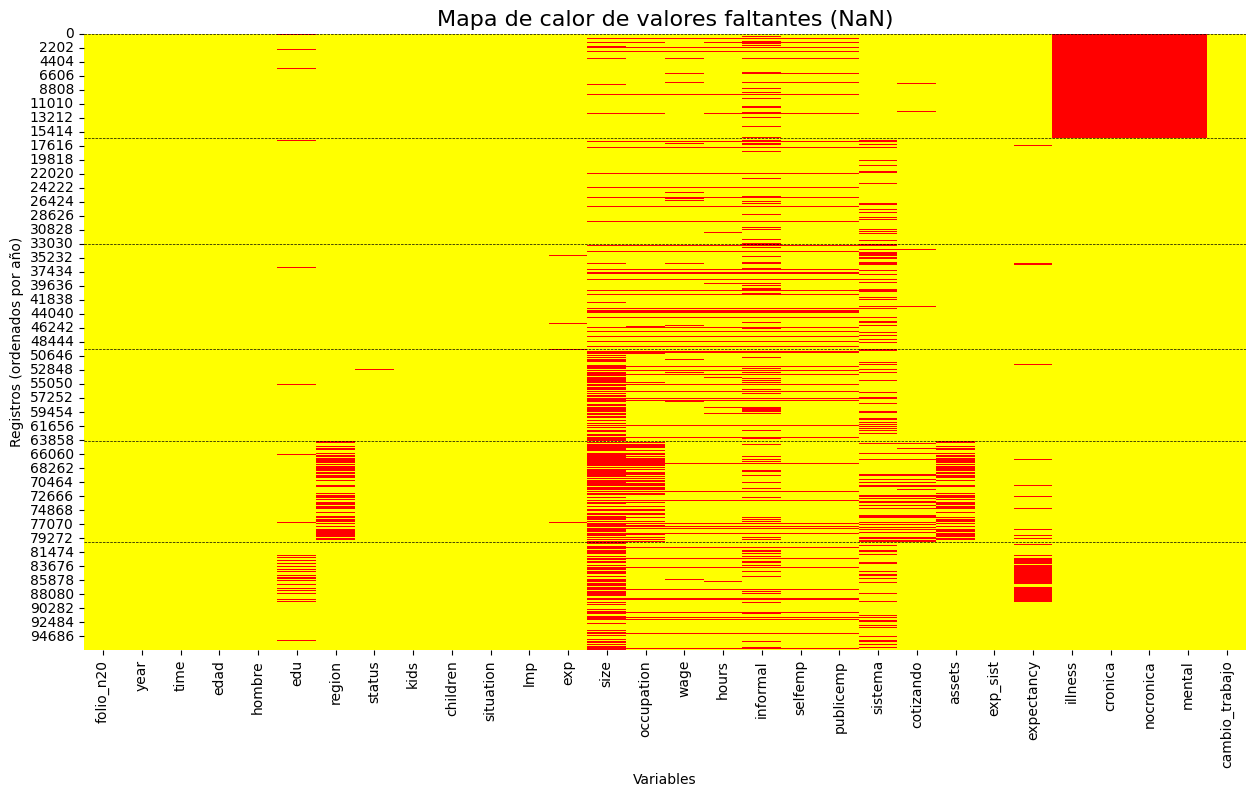

In [14]:
#VOLVEMOS A REALIZAR UN GRAFICO PARA ANALIZAR PROPORCIONES DE NAN SEGUN VARIABLE SEPARADO POR UNA LINEA SEGUN RONDA
# SE SIGUE NOTANDO UNA FUERTE TENDENCIA
#Asegurarte de que esté ordenado por año
df_03=df_02.copy()
df_03_sorted=df_03.sort_values(by='year').reset_index(drop=True)

#Encontrar los índices donde cambia el año
cambios_de_anio=df_03_sorted['year'].ne(df_03_sorted['year'].shift()).cumsum()
lineas_de_corte=df_03_sorted.groupby(cambios_de_anio).head(1).index.tolist()

#Generar el heatmap
plt.figure(figsize=(15, 8))
sns.heatmap(df_03_sorted.isnull(), cbar=False, cmap=sns.color_palette(["yellow", "red"]))
plt.title("Mapa de calor de valores faltantes (NaN)", fontsize=16)
plt.xlabel("Variables")
plt.ylabel("Registros (ordenados por año)")

#Dibujar líneas horizontales donde cambia el año
for i in lineas_de_corte:
    plt.axhline(i, color='black', linestyle='--', linewidth=0.5)

plt.show()

In [15]:
# Total de folios únicos en todo el dataset
total_folios=len(df_02['folio_n20'])
# Cantidad de folios únicos por ronda
folios_por_ronda=df_02.groupby('time')['folio_n20'].nunique().sort_index()
# Porcentaje
porcentaje_por_ronda=(folios_por_ronda / total_folios)*100
# Mostrar en un DataFrame
df_porcentajes=pd.DataFrame({'ronda': folios_por_ronda.index,'cantidad_folios': folios_por_ronda.values,'porcentaje': porcentaje_por_ronda.round(2).values})
print(df_porcentajes)


   ronda  cantidad_folios  porcentaje
0      1            16309       16.84
1      2            16727       17.27
2      3            16443       16.98
3      4            14463       14.93
4      5            15998       16.52
5      6            16906       17.46


In [16]:
df_03=df_03.drop(['size','edad','hombre'],axis=1)
df_03=df_03.drop(['kids','hours'],axis=1)

In [17]:
#Si bien se sigue notando una fuerte tendencia de falta de datos dentro de lo que es la 1ra ronda en enfermedades, 4ta,5ta y 6ta en size y 5ta ronda en region y assets, se asume 
# parte de la perida de los datos al aplicar dropna, dado que seguir intentando trabajar los dastos para reducir la proporción de nan seria involucrarse de mayor manera en el 
# tratamieto de los datos pudiendo generar posteriormente una modificación den las estimaciones de los modelos
df_03=df_03.dropna()

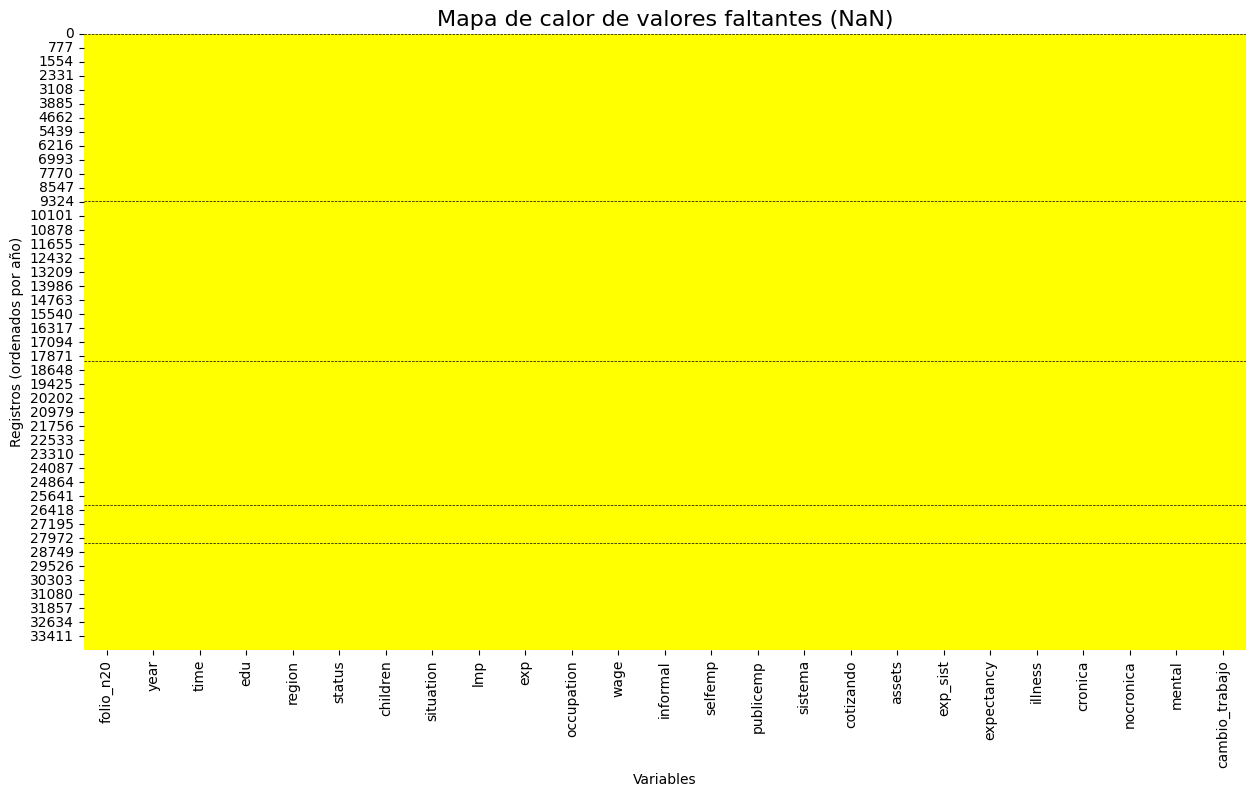

In [18]:
#VOLVEMOS A REALIZAR UN GRAFICO PARA ANALIZAR PROPORCIONES DE NAN SEGUN VARIABLE SEPARADO POR UNA LINEA SEGUN RONDA
# SE SIGUE NOTANDO UNA FUERTE TENDENCIA
#Asegurarte de que esté ordenado por año
df_03_sorted=df_03.sort_values(by='year').reset_index(drop=True)

#Encontrar los índices donde cambia el año
cambios_de_anio=df_03_sorted['year'].ne(df_03_sorted['year'].shift()).cumsum()
lineas_de_corte=df_03_sorted.groupby(cambios_de_anio).head(1).index.tolist()

#Generar el heatmap
plt.figure(figsize=(15, 8))
sns.heatmap(df_03_sorted.isnull(), cbar=False, cmap=sns.color_palette(["yellow", "red"]))
plt.title("Mapa de calor de valores faltantes (NaN)", fontsize=16)
plt.xlabel("Variables")
plt.ylabel("Registros (ordenados por año)")

#Dibujar líneas horizontales donde cambia el año
for i in lineas_de_corte:
    plt.axhline(i, color='black', linestyle='--', linewidth=0.5)

plt.show()

In [19]:
# Total de folios únicos en todo el dataset
total_folios=len(df_03['folio_n20'])
# Cantidad de folios únicos por ronda
folios_por_ronda=df_03.groupby('time')['folio_n20'].nunique().sort_index()
# Porcentaje
porcentaje_por_ronda=(folios_por_ronda / total_folios)*100
# Mostrar en un DataFrame
df_porcentajes=pd.DataFrame({'ronda': folios_por_ronda.index,'cantidad_folios': folios_por_ronda.values,'porcentaje': porcentaje_por_ronda.round(2).values})
print(df_porcentajes)


   ronda  cantidad_folios  porcentaje
0      2             9276       27.16
1      3             8883       26.00
2      4             7990       23.39
3      5             2093        6.13
4      6             5917       17.32


In [20]:
#Pasar variables categoricas a dummies

# Variables categóricas a transformar
categoricas=['region', 'status', 'situation', 'lmp', 'occupation','year']
# Convertir a tipo category (si aún no lo son)
df_03[categoricas]=df_03[categoricas].astype('category')

# Generar dummies
df_04=pd.get_dummies(df_03, columns=categoricas, drop_first=True).astype(int)

In [21]:
df_04

,folio_n20,time,edu,children,exp,wage,informal,selfemp,publicemp,sistema,...,occupation_5.0,occupation_6.0,occupation_7.0,occupation_8.0,occupation_9.0,occupation_10.0,year_6,year_9,year_12,year_15
5,6154351,2,15,3,6,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
7,6158824,2,4,0,23,100000,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
8,6158824,3,3,0,26,90000,0,0,0,1,...,0,0,0,0,1,0,1,0,0,0
9,6158824,4,3,0,29,170000,0,0,0,1,...,0,0,0,0,1,0,0,1,0,0
10,6158824,5,3,0,29,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95983,-724676419,6,3,0,5,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
95991,-724658669,3,3,2,0,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0
95999,-724643049,6,1,0,25,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
96006,-724632399,6,5,0,2,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


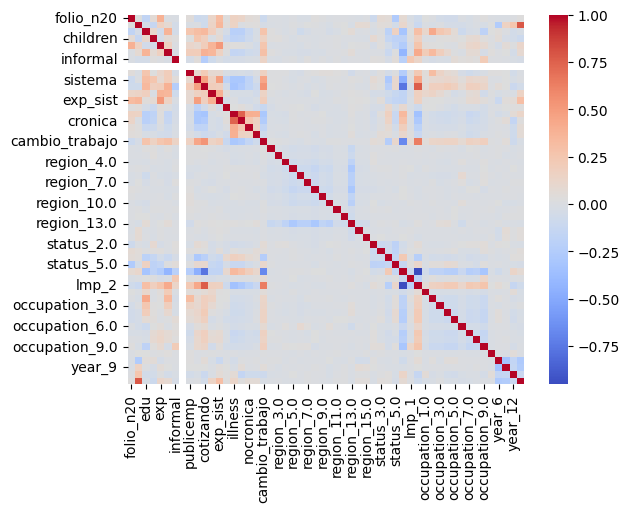

In [22]:
correlation_matrix=df_04.corr()
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False)
plt.show()

In [23]:
#REVISAMOS LAS CORRELACIONES SOBRE 0.8 O BAJO -0.8 PARA PREVEER MULTICOLINEALIDAD

upper=correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
high_corr=upper.stack().reset_index()
high_corr.columns=['Variable1', 'Variable2', 'Correlacion']
high_corr_filtrada=high_corr[(high_corr['Correlacion'] > 0.8) | (high_corr['Correlacion'] < -0.8)]
print(high_corr_filtrada.sort_values(by='Correlacion', ascending=False))


        Variable1 Variable2  Correlacion
1243  situation_4     lmp_2    -0.952003


In [24]:
df_04=df_04.drop(['lmp_2','selfemp'],axis=1) #situation_4 lmp_2 dicen casi lo mismo y SELFEMP PURO 0

## 2. Ejecute un modelo Pooled OLS para estimar la relacion entre los años de educación y la expectativa de vida. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.

**R:**  El modelo Pooled OLS explica el 6.2% de la varianza en la expectativa de vida. La variable edu (años de educación) tiene un coeficiente negativo (-0.0152) y no es estadísticamente significativa (p=0.2881), por lo que no se puede concluir que tenga un efecto claro sobre la expectativa de vida.
Entre las variables con efectos negativos y significativos se destacan mental (-2.0938, p < 0.0001), asociada a problemas de salud mental; sistema (-4.6592, p < 0.0001), que refleja diferencias por tipo de sistema de salud; illness (-0.6417, p=0.0020), nocronica (-0.8020, p=0.0001) e informal (-0.8344, p=0.0001), relacionadas con condiciones de salud y precariedad laboral.

Por otro lado, las variables exp (0.0399, p < 0.0001), wage (6.33e-07, p=0.0011) y assets (3.02e-08, p < 0.0001) tienen efectos positivos y significativos, lo que indica que la experiencia laboral, los ingresos y los activos están asociados con una mayor expectativa de vida. También destacan algunas ocupaciones como occupation_1.0 (1.2417, p=0.0474) y occupation_2.0 (0.7479, p=0.0188), así como las variables de año, que muestran una tendencia positiva a lo largo del tiempo.En síntesis, si bien la educación no resultó significativa, factores económicos, de salud y ocupacionales muestran un impacto importante en la expectativa de vida, junto con años que ademas de ser significativas y con un coeciciente razonable, su impacto va en aumento a medida que avanzan los años(coedicientes de year_6,year_9,year_12 y year_15)

In [25]:
df_panel=df_04.set_index(['folio_n20', 'time'])

In [26]:
indices=['folio_n20', 'time']

continuas=df_panel[['edu', 'children', 'exp',  'wage', 
             'assets', 'exp_sist']]
binarias=df_panel[[ 'publicemp', 'sistema', 
             'illness', 'cronica', 'nocronica', 'mental', 
             'informal']]
categoricas=df_panel[['region_2.0', 'region_3.0', 'region_4.0', 'region_5.0',
               'region_6.0', 'region_7.0', 'region_8.0', 'region_9.0', 'region_10.0',
               'region_11.0', 'region_12.0', 'region_13.0', 'region_14.0', 'region_15.0',
                'status_2.0', 'status_3.0', 'status_4.0', 'status_5.0',
                'lmp_1',  'occupation_1.0', 'occupation_2.0', 'occupation_3.0',
               'occupation_4.0', 'occupation_5.0', 'occupation_6.0', 'occupation_7.0',
               'occupation_8.0', 'occupation_9.0', 'occupation_10.0','year_12', 'year_6', 'year_9', 'year_15']]


In [27]:
# Definir variables
Y=df_panel['expectancy']
X=pd.concat([continuas, binarias, categoricas], axis=1)

X=sm.add_constant(X)

# Estimar modelo Pooled OLS (sin constantes adicionales)
modelo=lmp.PanelOLS(Y, X)
resultado=modelo.fit()
print(resultado)

                          PanelOLS Estimation Summary                           
Dep. Variable:             expectancy   R-squared:                        0.0620
Estimator:                   PanelOLS   R-squared (Between):              0.0845
No. Observations:               34159   R-squared (Within):              -0.0019
Date:                Fri, May 23 2025   R-squared (Overall):              0.0620
Time:                        22:47:07   Log-likelihood                -1.262e+05
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      48.999
Entities:                       14645   P-value                           0.0000
Avg Obs:                       2.3325   Distribution:                F(46,34112)
Min Obs:                       1.0000                                           
Max Obs:                       5.0000   F-statistic (robust):             48.999
                            

## 3. Ejecute un modelo efectos fijos para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.

**R:** El modelo de efectos fijos explica el 2.62% de la variabilidad dentro de las entidades en la expectativa de vida. La variable edu (años de educación) presenta un coeficiente positivo (0.0162) pero no es estadísticamente significativa (p=0.5806), por lo que no se puede afirmar que la educación impacte claramente en la expectativa de vida dentro de cada individuo a lo largo del tiempo.
Entre las variables significativas, la experiencia laboral (exp) tiene un efecto positivo importante (0.1043, p=0.0104), indicando que más años de experiencia se asocian con mayor expectativa de vida. La variable de salud mental (mental) muestra un efecto negativo y significativo (-0.4745, p=0.0456), sugiriendo que problemas de salud mental disminuyen la expectativa de vida.

Además, algunas ocupaciones tienen efectos positivos: occupation_2.0 (1.4721, p=0.0005) y occupation_3.0 (0.8007, p=0.0230), mientras que las variables que representan años (year_6, year_9, year_12, year_15) muestran un aumento progresivo y significativo en la expectativa de vida, reflejando una tendencia temporal positiva al igual que en el modelo Pooled OLS.
Otras variables, como los ingresos (wage), activos (assets) o variables de salud crónica no resultaron significativas en este modelo.
En resumen, en el modelo de efectos fijos la educación no tiene un efecto claro sobre la expectativa de vida, pero la experiencia laboral, la salud mental y ciertas ocupaciones sí muestran un impacto relevante dentro de cada individuo a lo largo del tiempo

In [28]:
model=lmp.PanelOLS(Y,X, entity_effects=True, drop_absorbed=True)
fe=model.fit(cov_type="robust")
print(fe)

                          PanelOLS Estimation Summary                           
Dep. Variable:             expectancy   R-squared:                        0.0262
Estimator:                   PanelOLS   R-squared (Between):             -0.0751
No. Observations:               34159   R-squared (Within):               0.0262
Date:                Fri, May 23 2025   R-squared (Overall):             -0.0484
Time:                        22:47:09   Log-likelihood                -1.047e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      11.400
Entities:                       14645   P-value                           0.0000
Avg Obs:                       2.3325   Distribution:                F(46,19468)
Min Obs:                       1.0000                                           
Max Obs:                       5.0000   F-statistic (robust):             8.3163
                            

## 4. Ejecute un modelo de efectos aleatorios para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado. 

**R:** El modelo de efectos aleatorios explica aproximadamente el 5.87% de la variabilidad total en la expectativa (expectancy). La variable edu (años de educación) presenta un coeficiente negativo (-0.0213) pero no es estadísticamente significativa (p=0.1565), por lo que no se puede concluir que la educación tenga un impacto claro sobre la expectativa.
Entre las variables significativas, tener hijos (children) tiene un efecto negativo importante (-0.5239, p < 0.0001), indicando que las responsabilidades familiares se asocian con una menor expectativa. La experiencia laboral (exp) presenta un efecto positivo y significativo (0.0530, p < 0.0001), sugiriendo que más años de experiencia aumentan la expectativa.

Las variables relacionadas con la salud muestran efectos negativos significativos: illness (-0.5044, p=0.0036), nocronica (-0.5251, p=0.0035) y especialmente mental (-1.2529, p < 0.0001), indicando que problemas de salud, en particular los mentales, reducen la expectativa.
En cuanto a la situación laboral, el empleo informal (informal) también disminuye la expectativa (-0.5946, p=0.0039). Algunas ocupaciones presentan efectos positivos, como occupation_2.0 (0.9244, p=0.0023), mientras que otras, como occupation_5.0, occupation_6.0 y occupation_9.0, muestran efectos negativos significativos.
Las variables temporales (year_6, year_9, year_12, year_15) tienen coeficientes positivos y significativos, reflejando un aumento progresivo en la expectativa a lo largo del tiempo, de igual forma que los dos modelos anteriores.

Por último, algunas regiones tienen impactos negativos significativos, como region_2.0 (-2.3325, p=0.0007) y region_8.0 (-1.1492, p=0.0485), evidenciando diferencias geográficas en la expectativa.
En resumen, en el modelo de efectos aleatorios, la educación no muestra un efecto claro sobre la expectativa, mientras que factores como la experiencia, la salud, la situación laboral, y el tiempo sí tienen impactos relevantes en la expectativa total de vida.

In [29]:
model=lmp.RandomEffects(Y,X)
re=model.fit(cov_type="robust")
print(re)

                        RandomEffects Estimation Summary                        
Dep. Variable:             expectancy   R-squared:                        0.4878
Estimator:              RandomEffects   R-squared (Between):              0.0752
No. Observations:               34159   R-squared (Within):               0.0113
Date:                Fri, May 23 2025   R-squared (Overall):              0.0587
Time:                        22:47:12   Log-likelihood                -1.143e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      706.15
Entities:                       14645   P-value                           0.0000
Avg Obs:                       2.3325   Distribution:                F(46,34112)
Min Obs:                       1.0000                                           
Max Obs:                       5.0000   F-statistic (robust):             32.617
                            

## 5. Comente los resultados obtenidos en 2, 3 y 4. ¿Cuáles y por qué existen las diferencias entre los resultados?. En su opinión, ¿Cuál sería el más adecuado para responder la pregunta de investgación y por qué? ¿Qué variables resultaron ser robustas a la especificación?

**R:** En los modelos estimados, el modelo de efectos fijos (p3) explicó un bajo porcentaje de la variabilidad dentro de las entidades, mientras que el modelo de efectos aleatorios (p4) mostró un mayor porcentaje de explicación total, aunque ambos R-cuadrados indican que gran parte de la variabilidad queda sin explicar.

La prueba de Hausman arrojó un valor chi-cuadrado muy alto (682.29) con un p-valor prácticamente cero (3.52e-114), lo que indica que existe una diferencia significativa entre los estimadores de efectos fijos y aleatorios. Esto sugiere que el modelo de efectos aleatorios no es consistente para este caso, y que las correlaciones entre los efectos individuales y las variables explicativas son importantes. Por lo tanto, el modelo de efectos fijos sería el más adecuado para responder la pregunta de investigación, ya que controla adecuadamente por la heterogeneidad no observada correlacionada con las variables independientes.

Respecto al modelo de regresión pooled OLS (p2), sus resultados son menos confiables porque no consideran la estructura de panel ni las heterogeneidades individuales, lo que puede sesgar los coeficientes.
En cuanto a las variables robustas a la especificación, la experiencia laboral (exp) mostró un efecto positivo y significativo en todos los modelos, lo que evidencia un impacto consistente en la expectativa. Por otro lado, variables relacionadas con la salud mental (mental) y el número de hijos (children) también mostraron efectos significativos en ambos modelos de efectos fijos y aleatorios, aunque la magnitud y significancia varían.

En resumen, el modelo de efectos fijos es preferible dado el resultado del test de Hausman y porque permite controlar por efectos no observados individuales correlacionados con las variables explicativas, garantizando estimadores consistentes. Las variables relacionadas con experiencia laboral, salud mental y responsabilidades familiares resultaron ser robustas a la especificación del modelo.

In [30]:
def hausman(fe, re):
 diff=fe.params-re.params
 psi=fe.cov-re.cov
 dof=diff.size -1
 W=diff.dot(la.inv(psi)).dot(diff)
 pval=stats.chi2.sf(W, dof)
 return W, dof, pval

htest=hausman(fe, re) 
print("Hausman Test: chi-2={0}, df={1}, p-value={2}".format(htest[0], htest[1], htest[2]))

Hausman Test: chi-2=682.2854891965596, df=46, p-value=3.517830718549534e-114


...

## 6. Ejecute un modelo de efectos aleatorios correlacionados (CRE) para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado. Es este modelo adecuado, dada la data disponible, para modelar el componente no observado?

**R:** Se estimó un modelo de efectos aleatorios correlacionados (CRE) para analizar los factores que inciden en la expectativa laboral, incorporando tanto las variables individuales como sus promedios por individuo, lo que permite separar los efectos dentro del individuo (variación temporal) y entre individuos (heterogeneidad no observada). El modelo obtuvo un R² overall de 0.0712, lo que indica un ajuste razonable considerando la complejidad del fenómeno.

Se observaron efectos significativos de variables como experiencia laboral, salud mental, y los años de medición, lo que sugiere que estos factores influyen en las expectativas. A nivel de promedios, variables como m\_children, m\_exp, m\_assets, m\_sistema y m\_mental también fueron significativas, lo que confirma la relevancia de capturar diferencias estructurales entre personas.
La inclusión de los promedios de las variables en el modelo permite controlar por la heterogeneidad no observada, lo cual lo hace adecuado dada la naturaleza del panel y la pregunta de investigación. Por tanto, el CRE es una elección metodológica apropiada para este análisis.


In [32]:
# Dentro de las variables a trabajar no seran consideradas regiones(pueden ser muy numerosos y colineales)
#ocupaciones (que no fueron significativos o que tienen pocos datos) y lmp_1 si resultó no significativa y no tiene importancia teórica
var = [
    'edu', 'children', 'exp', 'wage', 'assets', 'exp_sist', 
    'publicemp', 'sistema', 'illness', 'cronica', 'nocronica', 
    'mental', 'informal',
    'status_2.0', 'status_3.0', 'status_4.0', 'status_5.0',
    'occupation_2.0', 'occupation_3.0', 'occupation_5.0', 
    'occupation_6.0', 'occupation_9.0',
    'year_6', 'year_9', 'year_12', 'year_15'
]
Xm=df_panel.groupby('folio_n20')[var].transform('mean')
Xm.columns=['m_'+col for col in Xm.columns]  # Renombrar
X_cre=pd.concat([X, Xm], axis=1)
model=lmp.RandomEffects(Y, X_cre)
cre=model.fit(cov_type="robust")
print(cre.summary)

                        RandomEffects Estimation Summary                        
Dep. Variable:             expectancy   R-squared:                        0.4948
Estimator:              RandomEffects   R-squared (Between):              0.0885
No. Observations:               34159   R-squared (Within):               0.0245
Date:                Fri, May 23 2025   R-squared (Overall):              0.0712
Time:                        22:47:17   Log-likelihood                -1.141e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      463.68
Entities:                       14645   P-value                           0.0000
Avg Obs:                       2.3325   Distribution:                F(72,34086)
Min Obs:                       1.0000                                           
Max Obs:                       5.0000   F-statistic (robust):             28.119
                            

## 7. Usando el modelo CRE, prediga la distribucion del componente no observado. Que puede inferir respecto de la heterogeneidad fija en el tiempo y su impacto en la expectativa de vida?

**R:** Observando el gráfico, notamos que la distribución del componente no observado es más concentrada y suave que la distribución real de la expectativa de vida, la cual muestra picos más definidos y una mayor dispersión. Esto indica que el componente no observado representa bien las diferencias estables entre personas como educación o condiciones de vida a largo plazo pero no captura completamente las variaciones específicas que ocurren de forma temporal o puntual.

En otras palabras, gran parte de lo que explica la expectativa de vida está relacionado con características constantes en el tiempo para cada persona. Pero también hay otros factores, cambios momentáneos o detalles individuales que el modelo no logra captar.
Por eso, podemos decir que la heterogeneidad fija tiene un papel importante, pero que para entender toda la variabilidad de la expectativa de vida sería útil considerar modelos que también incluyan esos efectos temporales o específicos.

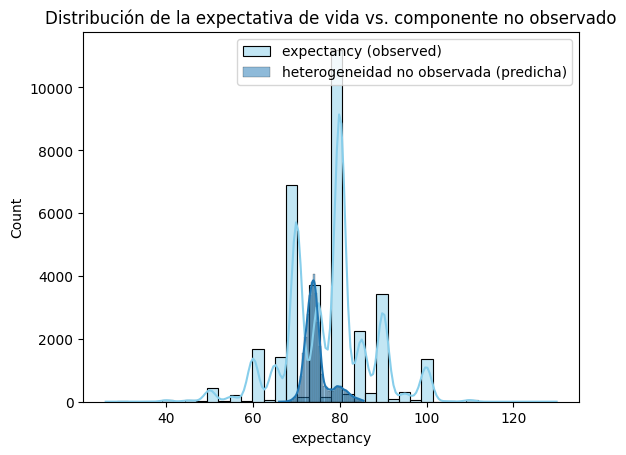

In [33]:
Xpred=X_cre.copy()

cols_to_zero= [
    'edu', 'children', 'exp', 'wage', 'assets', 'exp_sist',
    'publicemp', 'sistema', 'illness', 'cronica', 'nocronica',
    'mental', 'informal',
    'region_2.0', 'region_3.0', 'region_4.0', 'region_5.0',
    'region_6.0', 'region_7.0', 'region_8.0', 'region_9.0',
    'region_10.0', 'region_11.0', 'region_12.0', 'region_13.0',
    'region_14.0', 'region_15.0',
    'status_2.0', 'status_3.0', 'status_4.0', 'status_5.0',
    'lmp_1',
    'occupation_1.0', 'occupation_2.0', 'occupation_3.0',
    'occupation_4.0', 'occupation_5.0', 'occupation_6.0',
    'occupation_7.0', 'occupation_8.0', 'occupation_9.0',
    'occupation_10.0',
    'year_6', 'year_9', 'year_12', 'year_15'
]


for col in cols_to_zero:
    if col in Xpred.columns:
        Xpred[col]=0

yhat=cre.predict(Xpred)

# Visualización
sns.histplot(data=Y, color="skyblue", label="expectancy (observed)", kde=True, bins=40)
sns.histplot(data=yhat, color="red", label="heterogeneidad no observada (predicha)", kde=True, bins=40)

plt.title("Distribución de la expectativa de vida vs. componente no observado")
plt.legend()
plt.show()

## 8. Usando sus respuestas anteriores, que modelo prefiere? que se puede inferir en general respecto del efecto de las variables explicativas sobre la expectativa de vida?

**R:** Entre los modelos estimados, el modelo de efectos aleatorios correlacionados (CRE) es el preferido. Esto se debe a que presenta el mayor R² overall (0.0712), lo que indica un mejor ajuste general. Además, permite controlar la heterogeneidad no observada entre individuos al incluir los promedios de las variables explicativas, lo que mejora la interpretación causal.

En términos generales, se observa que la experiencia laboral (exp), la salud mental (mental), y algunas variables relacionadas con el sistema previsional y estado ocupacional tienen efectos significativos sobre la expectativa de vida. Por ejemplo, la salud mental tiene un efecto negativo tanto a nivel individual como promedio, lo que sugiere que el deterioro mental reduce la expectativa. También destacan efectos negativos de trabajar en el sector informal y tener enfermedades crónicas o no crónicas.
Finalmente, variables como los años (dummies temporales) también muestran un efecto positivo, lo que indica una tendencia creciente en las expectativas a lo largo del tiempo, posiblemente por cambios estructurales o mejoras en condiciones de vida. En conjunto, el modelo CRE captura tanto variaciones dentro como entre individuos, ofreciendo una visión más completa del fenómeno.


In [34]:
print(lmp.compare({"FE": fe, "RE": re, "CRE": cre}))

                             Model Comparison                             
                                    FE                RE               CRE
--------------------------------------------------------------------------
Dep. Variable               expectancy        expectancy        expectancy
Estimator                     PanelOLS     RandomEffects     RandomEffects
No. Observations                 34159             34159             34159
Cov. Est.                       Robust            Robust            Robust
R-squared                       0.0262            0.4878            0.4948
R-Squared (Within)              0.0262            0.0113            0.0245
R-Squared (Between)            -0.0751            0.0752            0.0885
R-Squared (Overall)            -0.0484            0.0587            0.0712
F-statistic                     11.400            706.15            463.68
P-value (F-stat)                0.0000            0.0000            0.0000
=====================    

...

9. Bonus track (optativo): Es posible que sus resultados anteriores tengan sesgo dado que quienes esperan vivir mas pueden estar incentivados a adquirir mas educacion. Proponga AL MENOS DOS instrumentos posibles para predecir el nivel de educacion de forma exogena, tal que se pueda corregir el sesgo y entender el efecto causal de las educacion en la expectativa de vida. Realice su estimacion considerando un modelo agrupado (ignorando el tiempo), y el modelo de panel.